# Lab 1: Random variable generation

## Advanced Statistical Estimation, Centrale Lille

This lab is about random variable generation, i.e. the ability to produce finite samples of random variables or vectors from a given distribution.
* First, we assume we have a uniform generator on $[0,1]$ (in NumPy, `np.random.rand`). Starting from this generator, the goal is to sample other distributions with simple methods, in particular inverse transform sampling.
* Then we study more sophisticated methods (acceptance-rejection, importance sampling).

For each question, **briefly justify the solution, then implement it**, and **compare with the theoretical density** using histograms or KDE.

**Report by Ugo Roccamatisi.**


In [1]:
# Importing usual libraries
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity

### Exercise 1 - Getting started: uniform distributions

**Q1**. Given $N$ samples from a uniform distribution on $[0,1]$, how can we obtain $N$ samples from a uniform distribution on $[a,b]$?

**Justification.** If $U\sim\mathcal U[0,1]$, then $a+(b-a)U\sim\mathcal U[a,b]$, since its CDF equals $(x-a)/(b-a)$ inside the interval.

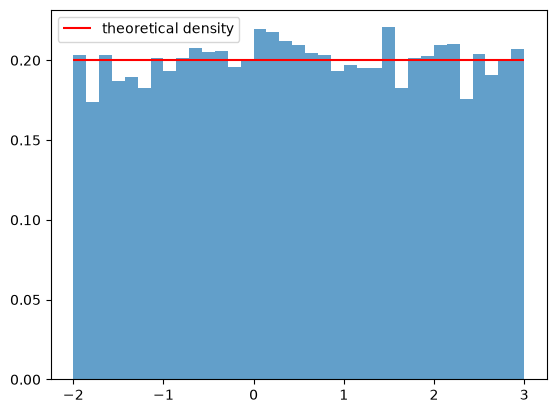

Empirical/theoretical mean: 0.5115956427998446 0.5


In [2]:
rng=np.random.default_rng(2025);N=10000;a,b=-2,3
U=rng.random(N);samples=a+(b-a)*U
fig,ax=plt.subplots();ax.hist(samples,bins=35,density=True,alpha=.7);ax.hlines(1/(b-a),a,b,color='r',label='theoretical density');ax.legend();plt.show()
print('Empirical/theoretical mean:',samples.mean(),(a+b)/2)

**Q2**. How can we obtain $N$ samples from a uniform distribution on the rectangle $[a,b] \times [c,d]$?

**Justification.** Draw two independent uniforms $U,V$ and return $(a+(b-a)U,c+(d-c)V)$; the joint density is $1/[(b-a)(d-c)]$ on the rectangle.

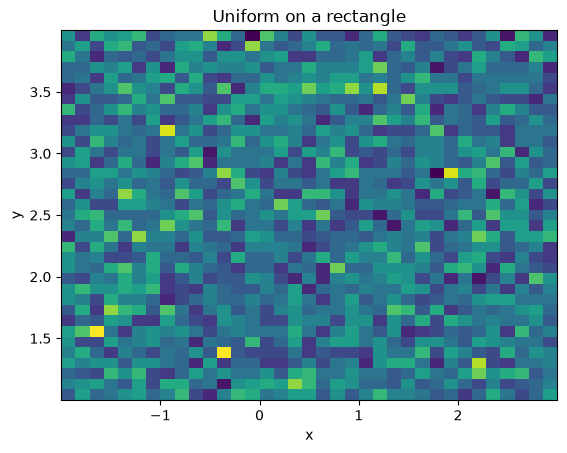

Theoretical mean: [0.5, 2.5] ; empirical mean: [0.46634926 2.49534671]


In [3]:
# Two independent uniform coordinates, hence a constant density on the rectangle.
c,d=1,4
points=np.column_stack((a+(b-a)*rng.random(N),c+(d-c)*rng.random(N)))
fig,ax=plt.subplots();ax.hist2d(*points.T,bins=35,cmap='viridis');ax.set(xlabel='x',ylabel='y',title='Uniform on a rectangle');plt.show()
print('Theoretical mean:',[(a+b)/2,(c+d)/2],'; empirical mean:',points.mean(axis=0))

**Q3**. Given $N$ samples from a uniform distribution on $[0,1]$, how can we obtain $N$ samples from a discrete uniform distribution on $\{1, ..., K\}$?

**Justification.** $J=1+\lfloor KU\rfloor$ takes each value $1,\dots,K$ with probability $1/K$ if $U\in[0,1[$.

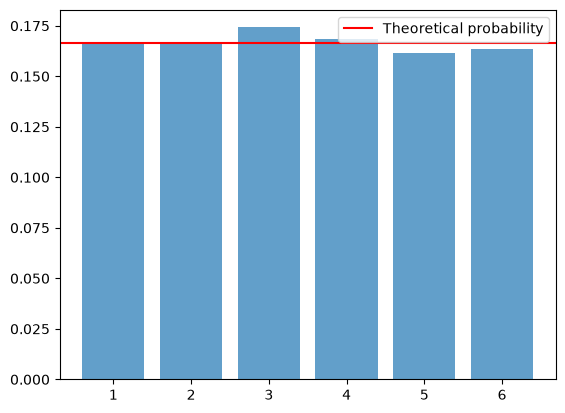

Frequencies of the 6 outcomes: [0.166 0.166 0.174 0.168 0.161 0.164]


In [4]:
K=6;discrete=np.floor(K*rng.random(N)).astype(int)+1
freq=np.bincount(discrete,minlength=K+1)[1:]/N
fig,ax=plt.subplots();ax.bar(np.arange(1,K+1),freq,alpha=.7);ax.axhline(1/K,c='r',label='Theoretical probability');ax.legend();plt.show()
print('Frequencies of the 6 outcomes:',np.round(freq,3))

### Exercise 2 - Inverse transform sampling

Let $X$ be a real random variable with CDF $F$ (recall: $F$ is a non-decreasing, right-continuous function from $\mathbb{R}$ to $[0,1]$, but not necessarily bijective). The **generalized inverse** $F^{-1}$ of $F$ is defined by:
$$\forall~u \in [0,1],~F^{-1}(u) = \inf\{x \in \mathbb{R}, F(x) \geq u\}.$$

This function coincides with the usual inverse when $F$ is bijective (note that even a continuous $F$ is not necessarily bijective: it may have plateaus). We have the following proposition:

If $U$ is uniform on $[0,1]$, then the random variable $F^{-1}(U)$ has CDF $F$ (and therefore the same distribution as $X$).


This gives the **inverse transform** method: if $F^{-1}$ is known explicitly, any real random variable can be simulated from a uniform sample.

**Q1**. Using this method, simulate $N$ samples from an exponential distribution with parameter $\lambda$.

**Justification.** $F(x)=1-e^{-\lambda x}$ for $x\ge0$, so $F^{-1}(u)=-\log(1-u)/\lambda$. In NumPy, `-log1p(-u)` is accurate when $u$ is small.

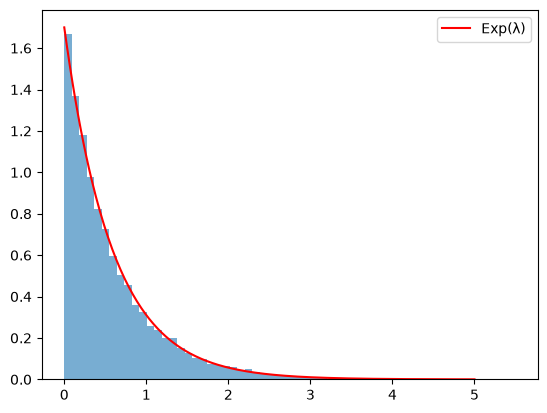

Empirical/theoretical mean: 0.5784389967804607 0.5882352941176471


In [5]:
from scipy import stats as ss
rate=1.7;U=rng.random(N)
exponential=-np.log1p(-U)/rate
fig,ax=plt.subplots();ax.hist(exponential,bins=60,density=True,alpha=.6);t=np.linspace(0,5,300);ax.plot(t,ss.expon.pdf(t,scale=1/rate),'r',label='Exp(λ)');ax.legend();plt.show()
print('Empirical/theoretical mean:',exponential.mean(),1/rate)

**Q2**. In your opinion, what are the limitations of the inverse transform method?

**Answer.** The quantile function must be known or computed numerically, which can be difficult; in several dimensions, the dependence between coordinates requires more than a marginal inversion. The generalized inverse does, however, handle discontinuities and plateaus.

### Exercise 3 - Box-Muller method

We have the following proposition:

Let $R \sim \text{Exp}(1/2)$ and $\Theta \sim U([0, 2 \pi])$ be two independent random variables.
    
Then $X = \sqrt{R} \cos(\Theta)$ and $Y = \sqrt{R} \sin(\Theta)$ are two independent $\mathcal{N}(0,1)$ random variables.

This is known as the **Box-Muller** method (1958), one of the reference methods for generating normal random variables.

**Q1 (Bonus)**. Prove the proposition.

**Proof (bonus).** Let $R=r^2$: if $R\sim\mathrm{Exp}(1/2)$, the radius has density $r e^{-r^2/2}$ on $r>0$. Since the angle is independent and uniform on $[0,2\pi]$, the joint density in polar coordinates is $r e^{-r^2/2}/(2\pi)$. The Cartesian Jacobian is $r$, so the density of $(X,Y)$ is $e^{-(x^2+y^2)/2}/(2\pi)=\phi(x)\phi(y)$, which gives independence and two standard normal distributions.

**Q2**. Deduce a way to generate $N$ samples from $\mathcal{N}(0,1)$ from samples of a uniform distribution on $[0,1]$.

**Justification.** Draw two independent uniforms $U_1,U_2$ and compute $\sqrt{-2\log U_1}\cos(2\pi U_2)$ and $\sqrt{-2\log U_1}\sin(2\pi U_2)$. Each pair gives two independent normals; one coordinate can be kept if N draws are needed.

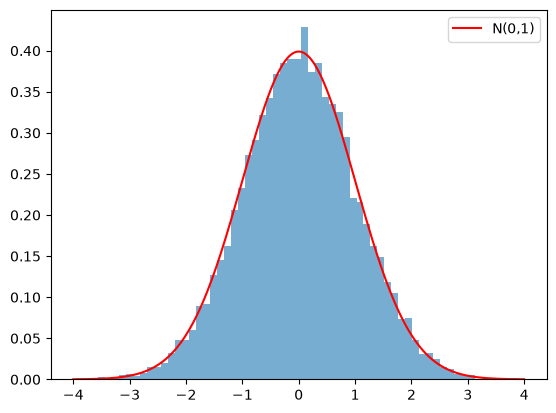

Empirical means, covariance: [ 0.019 -0.01 ] [[ 1.009 -0.018]
 [-0.018  1.013]]


In [6]:
# Two independent U produce a pair of independent normals.
U1=rng.random(N);U2=rng.random(N)
radius=np.sqrt(-2*np.log(U1));theta=2*np.pi*U2
normal_pair=np.column_stack((radius*np.cos(theta),radius*np.sin(theta)))
Z=normal_pair[:,0]
fig,ax=plt.subplots();ax.hist(Z,bins=60,density=True,alpha=.6);t=np.linspace(-4,4,300);ax.plot(t,ss.norm.pdf(t),'r',label='N(0,1)');ax.legend();plt.show()
print('Empirical means, covariance:',np.round(normal_pair.mean(axis=0),3),np.round(np.cov(normal_pair,rowvar=False),3))

**Q3**. Given $N$ samples from $\mathcal{N}(0,1)$, how can we obtain $N$ samples from $\mathcal{N}(\mu, \sigma^2)$?

**Justification.** If $Z\sim\mathcal N(0,1)$, then $\mu+\sigma Z\sim\mathcal N(\mu,\sigma^2)$ for $\sigma>0$.

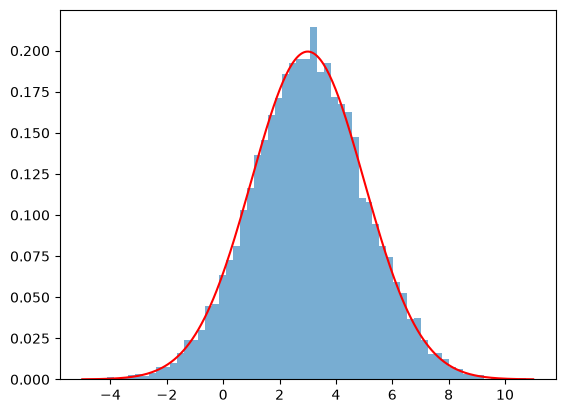

Empirical mean/variance: 3.0374456535035375 4.034370060891539 ; expected: 3.0 4.0


In [7]:
mu,sigma=3.0,2.0
normal_shifted=mu+sigma*Z
fig,ax=plt.subplots();ax.hist(normal_shifted,bins=60,density=True,alpha=.6);t=np.linspace(-5,11,300);ax.plot(t,ss.norm.pdf(t,loc=mu,scale=sigma),'r');plt.show()
print('Empirical mean/variance:',normal_shifted.mean(),normal_shifted.var(),'; expected:',mu,sigma**2)

**Q4**. We now want to simulate a Gaussian **vector** in dimension $d$.

Explain why the Box-Muller method can simulate vectors distributed as $\mathcal{N_d}(\mathbf{0}_d, I_d)$.

Let $X \sim \mathcal{N_d}(\mathbf{0}_d, I_d)$, $\mathbf{m} \in \mathbb{R}^d$, and $\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$ symmetric positive definite. Assume there exists $\mathbf{L} \in \mathbb{R}^{d \times d}$ such that $\boldsymbol{\Sigma} = \mathbf{L} \mathbf{L}^{\top}$.

Using the properties of Gaussian vectors, show that $Y = \mathbf{m} + \mathbf{L}X \sim \mathcal{N_d}(\mathbf{m}, \boldsymbol{\Sigma})$.

**Justification.** Box–Muller pairs built from independent uniforms provide as many independent normal coordinates as needed. For $X\sim\mathcal N_d(0,I_d)$, the affine map $Y=m+LX$ is Gaussian, with $E[Y]=m$ and $\mathrm{Cov}(Y)=LI_dL^\top=\Sigma$.

**Q5**. Such a matrix $\mathbf{L}$ can be shown to always exist. It is the **Cholesky decomposition** ($\mathbf{L}$ is lower triangular), a fundamental tool in statistics and machine learning. It is named after André-Louis Cholesky, a French military engineer who died during the First World War (the result was published posthumously in 1924). Note that the decomposition costs $\mathcal{O}(d^3)$!

From $N$ samples of $\mathcal{N_d}(\mathbf{0}_d, I_d)$, generate $N$ samples of $\mathcal{N_d}(\mathbf{m}, \boldsymbol{\Sigma})$. Take $d=2$ and use `np.linalg.cholesky`.

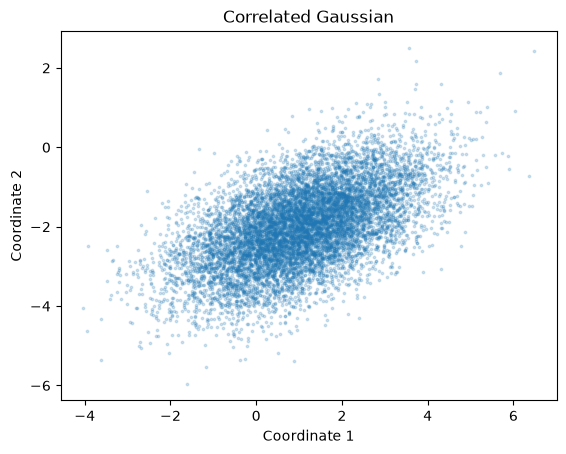

Empirical mean: [ 1.026 -1.997] theoretical: [ 1. -2.]
Empirical covariance:
 [[2.017 0.786]
 [0.786 0.994]] 
Theoretical:
 [[2.  0.8]
 [0.8 1. ]]


In [8]:
m=np.array([1.,-2.]);Sigma=np.array([[2.,.8],[.8,1.]])
L=np.linalg.cholesky(Sigma)
gaussian_vectors=m+normal_pair@L.T
fig,ax=plt.subplots();ax.scatter(*gaussian_vectors.T,s=3,alpha=.2);ax.set(xlabel='Coordinate 1',ylabel='Coordinate 2',title='Correlated Gaussian');plt.show()
print('Empirical mean:',np.round(gaussian_vectors.mean(axis=0),3),'theoretical:',m)
print('Empirical covariance:\n',np.round(np.cov(gaussian_vectors,rowvar=False),3),'\nTheoretical:\n',Sigma)

### Exercise 4 - Acceptance-rejection (*rejection sampling*)

**Q1**. Consider the Beta distribution, whose density on $[0,1]$ is
$$f(x;\alpha, \beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha) \Gamma(\beta)} x^{\alpha-1} (1-x)^{\beta-1} \quad \alpha > 0, \quad \beta > 0.$$

We want samples from the Beta distribution with $\alpha = 2, \beta = 2$.
* Explain why inverse transform sampling is difficult to apply here.
* Which very simple distribution can be used as the proposal?
* Implement an acceptance-rejection algorithm to obtain $N = 10000$ samples.
* Compare the empirical acceptance rate with its theoretical value.
* What difficulty arises for $\alpha = \beta = 0.5$?

**Justification.** The CDF of Beta(2,2) is $3x^2-2x^3$; inverting it requires solving a cubic polynomial, which is less convenient than acceptance-rejection. Take $g=\mathcal U[0,1]$, $M=\sup f/g=3/2$, and accept $x$ with probability $f(x)/(Mg(x))=4x(1-x)$; the theoretical acceptance probability is $1/M=2/3$. For Beta(1/2,1/2), the density diverges at the boundaries: no finite bound $M$ exists with a uniform proposal.

**Result.** The observed rate is 0.664 against 0.667 expected; the sample mean is 0.497, close to the theoretical mean of 0.5.


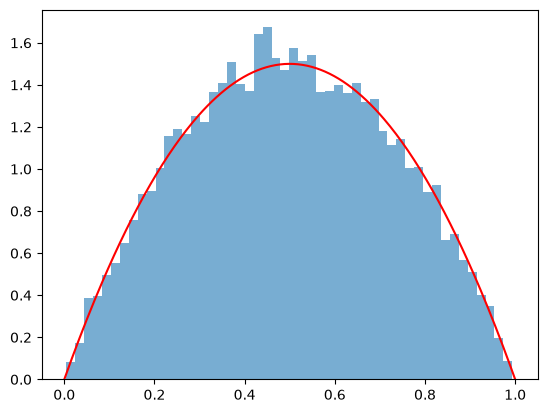

Accepted in batches / total proposed: 0.6638666666666667 ; theory: 0.6666666666666666
Sample mean: 0.49712005942504967


In [9]:
# f(x)=6x(1-x), g(x)=1 on [0,1], M=sup f/g=3/2.
M=1.5;accepted=[];total=0
while len(accepted)<N:
    proposals=rng.random(15000);height=rng.random(15000)
    mask=height<=4*proposals*(1-proposals)  # f/(M*g)=6x(1-x)/1.5.
    accepted.extend(proposals[mask]);total+=len(proposals)
beta_samples=np.array(accepted[:N])
fig,ax=plt.subplots();ax.hist(beta_samples,bins=50,density=True,alpha=.6);t=np.linspace(0,1,300);ax.plot(t,ss.beta.pdf(t,2,2),'r');plt.show()
print('Accepted in batches / total proposed:',len(accepted)/total,'; theory:',1/M)
print('Sample mean:',beta_samples.mean())

**Q2**. We now want samples from a truncated Gaussian distribution, i.e. a normal distribution restricted to an interval (in 1D) or to a box (in the multivariate case).

Consider a multivariate Gaussian $\mathcal{N}_d(0, I_d)$ truncated to the box $[-1,2]^d$. The proposal is the (untruncated) distribution $\mathcal{N}(0, I_d)$.

* Justify this choice of proposal.
* In the univariate case ($d=1$), compute numerically the acceptance probability of the acceptance-rejection algorithm. `scipy.stats.cdf` can be used.
* What does this probability become for $d=10$? $d=100$? Conclude on the fundamental weakness of acceptance-rejection.

**Justification.** Proposing $Z\sim\mathcal N_d(0,I_d)$ directly and keeping only $Z\in[-1,2]^d$ yields the desired truncated distribution. With $p=\Phi(2)-\Phi(-1)$, the acceptance probability is $p^d$ because the coordinates are independent. In high dimension it becomes tiny: the method wastes almost every draw.

**Result.** The acceptance probability is about 0.819 in dimension 1, 0.135 in dimension 10 and 2.03 × 10⁻⁹ in dimension 100: the last case needs on average about 493 million proposals per accepted draw.


In [10]:
p1=ss.norm.cdf(2)-ss.norm.cdf(-1)
for d in (1,10,100):print(f'd={d}: acceptance probability={p1**d:.5g}, mean trials={1/p1**d:.5g}')
# The conditional distribution can be sampled by keeping only the draws inside the box.
candidates=rng.normal(size=(30000,2));inside=np.all((-1<=candidates)&(candidates<=2),axis=1)
print('Empirical rate d=2:',inside.mean(),'; theoretical rate:',p1**2)

d=1: acceptance probability=0.81859, mean trials=1.2216
d=10: acceptance probability=0.13511, mean trials=7.4014
d=100: acceptance probability=2.0272e-09, mean trials=4.933e+08
Empirical rate d=2: 0.6728 ; theoretical rate: 0.6700971422668672


### Exercise 5 - Monte Carlo estimation of $\pi$

Recall that $\pi$ is the area of a disk of radius 1, i.e.
$$ \pi = \int_{-1}^1 \int_{-1}^1 \mathbb{1}_{x^2 + y^2 \leq 1}(x,y) dx dy.$$

This can be rewritten as
$$ \pi = 4 \int_{-1}^1 \int_{-1}^1 \mathbb{1}_{x^2 + y^2 \leq 1}(x,y) p(x) p(y) dx dy,$$
where $p(x)$ and $p(y)$ are the densities of the uniform distribution on $[-1,1]$.

* Deduce the Monte Carlo estimator of $\pi$.
* Generate $N_s = 10000$ samples, then plot the Monte Carlo estimate of $\pi$ obtained with the first $N$ samples only. Which fundamental result does this illustrate?
* Run 1000 Monte Carlo estimations of $\pi$ with $N_s = 10000$ samples each, and check the convergence in distribution of the Monte Carlo estimator given by the CLT.

**Justification.** For $(X_i,Y_i)$ independent and uniform on $[-1,1]^2$, $\hat\pi_N=4N^{-1}\sum_i\mathbf 1_{X_i^2+Y_i^2\le1}$. The law of large numbers ensures $\hat\pi_N\to\pi$; the CLT gives an approximately normal distribution with mean $\pi$ and variance $16(\pi/4)(1-\pi/4)/N$.

**Result.** Over 1000 repetitions, the mean estimate is 3.1407 and the standard deviation 0.01657, close to the 0.01642 predicted by the CLT.


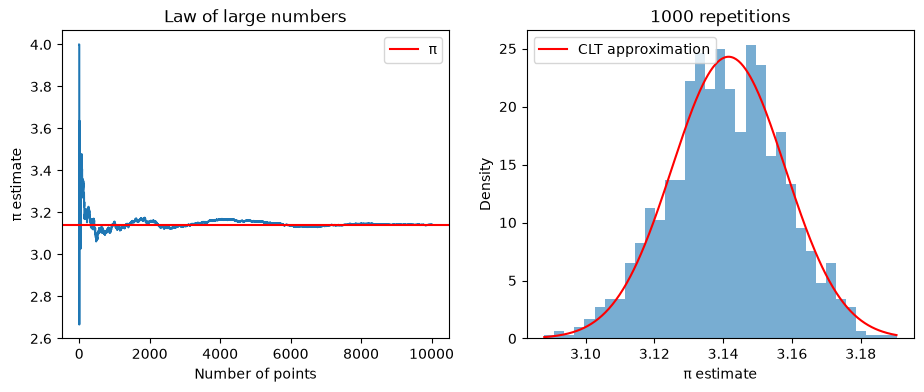

Empirical mean/sd: 3.1407216 0.016567240171099312 ; CLT sd: 0.01642183367736324


In [11]:
Ns=10000;xy=rng.uniform(-1,1,size=(Ns,2));inside=(xy**2).sum(axis=1)<=1
running=4*np.cumsum(inside)/np.arange(1,Ns+1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(running);axes[0].axhline(np.pi,c='r',label='π');axes[0].set(xlabel='Number of points',ylabel='π estimate',title='Law of large numbers');axes[0].legend()
repetitions=1000;estimates=np.empty(repetitions)
for i in range(repetitions):
    pts=rng.uniform(-1,1,size=(Ns,2));estimates[i]=4*np.mean((pts**2).sum(axis=1)<=1)
# CLT: theoretical standard deviation of 4*Bernoulli(p), p=π/4.
theoretical_sd=4*np.sqrt((np.pi/4)*(1-np.pi/4)/Ns)
t=np.linspace(estimates.min(),estimates.max(),300)
axes[1].hist(estimates,bins=35,density=True,alpha=.6);axes[1].plot(t,ss.norm.pdf(t,np.pi,theoretical_sd),'r',label='CLT approximation')
axes[1].set(xlabel='π estimate',ylabel='Density',title='1000 repetitions');axes[1].legend();plt.show()
print('Empirical mean/sd:',estimates.mean(),estimates.std(ddof=1),'; CLT sd:',theoretical_sd)

### Exercise 6 - Importance sampling

We want to estimate $\mathbb{P}(X > 3)$ with $X \sim \mathcal{N}(0,1)$.

* Rewrite this probability as an integral and deduce the "standard" Monte Carlo estimator.
* Simulate $N_s = 10000$ samples $1000$ times, and compute the empirical mean and variance of the standard Monte Carlo estimator.
* We now implement importance sampling with the proposal $\mathcal{N}(4,1)$. Give the corresponding Monte Carlo estimator.
* Likewise, simulate $N_s = 10000$ samples $1000$ times, and compute the empirical mean and variance of this second estimator.
* Quantify the variance reduction. Comment.

**Justification.** The target probability is $\int_3^\infty\phi(x)dx$. Standard MC: the mean of $\mathbf 1_{X_i>3}$ with $X_i\sim\phi$. With $Z_i\sim g=\mathcal N(4,1)$: the mean of $\mathbf 1_{Z_i>3}\phi(Z_i)/g(Z_i)$. The weights correct for the change of distribution, and concentrating the draws in the rare region can reduce the variance.

**Result.** Both means are close to the true value 0.0013499. The empirical variance drops from 1.29 × 10⁻⁷ to 9.32 × 10⁻¹⁰, a reduction of about **139 times**.


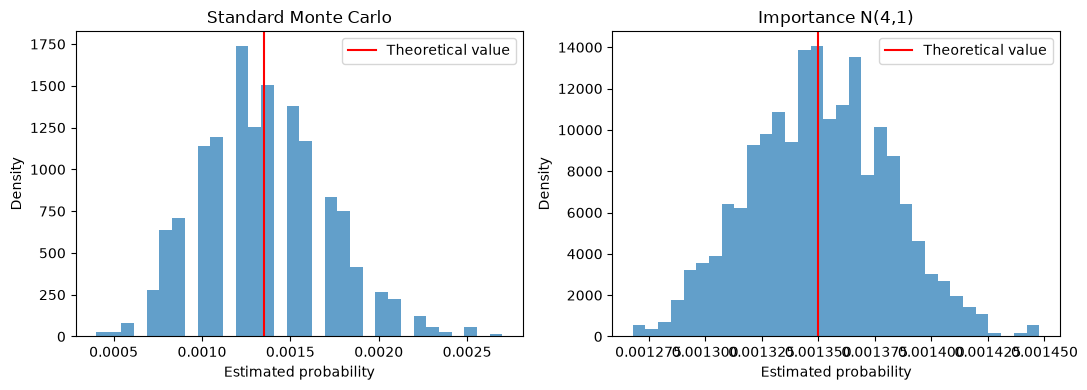

Truth: 0.0013498980316300933
Standard MC: mean 0.0013540999999999998 variance 1.2945264264264264e-07
Importance: mean 0.0013507442151562627 variance 9.315779771321513e-10
Variance reduction factor: 138.96060858068012


In [12]:
Ns=10000;repetitions=1000
standard=np.empty(repetitions);importance=np.empty(repetitions)
for i in range(repetitions):
    x=rng.normal(size=Ns);standard[i]=np.mean(x>3)
    z=rng.normal(loc=4,size=Ns)
    weights=np.exp(ss.norm.logpdf(z)-ss.norm.logpdf(z,loc=4))
    importance[i]=np.mean((z>3)*weights)
truth=ss.norm.sf(3)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,s,title in zip(axes,(standard,importance),('Standard Monte Carlo','Importance N(4,1)')):
    ax.hist(s,bins=32,density=True,alpha=.7);ax.axvline(truth,color='r',label='Theoretical value');ax.set(xlabel='Estimated probability',ylabel='Density',title=title);ax.legend()
fig.tight_layout();plt.show()
print('Truth:',truth)
print('Standard MC: mean',standard.mean(),'variance',standard.var(ddof=1))
print('Importance: mean',importance.mean(),'variance',importance.var(ddof=1))
print('Variance reduction factor:',standard.var(ddof=1)/importance.var(ddof=1))